# Projeto - Análise e Preparação de Dados
## Inteligência Artificial e Ciência de Dados / PUCPR

**Prof. Jean Paul Barddal**

`Dani`

`Erica Sousa`

`Leandro Rodrigues Carneiro`

`Nathália Jucá Monteiro`

In [1]:
import os
import json
import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
files_id = ["1ERBzQWURAhvxePxMWaBCmirR7NwORt8F"]
file_path = os.path.join("data", "food_delivery_analytics_cleaned.csv")
for file_id in files_id:
    gdown.download(
        f"https://drive.google.com/uc?id={file_id}",
        file_path,
        quiet=False
    )

Downloading...
From: https://drive.google.com/uc?id=1ERBzQWURAhvxePxMWaBCmirR7NwORt8F
To: c:\Users\Leandro\Documents\codigos\pos_graduacao\pos_graduacao_analise_preparacao_dados\data\food_delivery_analytics_cleaned.csv
100%|██████████| 3.66M/3.66M [00:00<00:00, 8.52MB/s]


In [24]:
try:
    df = pd.read_csv(file_path)
    print('Arquivo carregado com sucesso!')
    display(df.head())
except FileNotFoundError:
    print(f"Erro: O arquivo não foi encontrado no caminho especificado: {file_path}")
except Exception as e:
    print(f"Ocorreu um erro ao ler o arquivo: {e}")

Arquivo carregado com sucesso!


,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,68,5.4,2.6,4.3,4.1,2.9,100.000000,14.592602,22.969359,19.940541,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,40,1.0,1.6,4.0,4.2,3.4,100.000000,4.391720,4.434405,16.101949,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,142,8.3,4.1,4.4,4.2,3.7,100.000000,9.006407,14.979691,17.681454,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,93,3.2,8.8,4.8,4.6,4.1,145.113442,11.407034,14.813044,11.593912,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,134,7.5,9.5,4.0,3.9,4.6,100.000000,11.572232,13.716308,13.272883,111.128807,2,True,False,False,False,False,False,6,25.1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  str    
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  float64
 12  w

In [ ]:
df.isnull().sum() / len(df) *100 

order_id                             0.0
city_tier                            0.0
customer_age                         0.0
customer_loyalty_score               0.0
order_hour                           0.0
order_day_of_week                    0.0
order_month                          0.0
delivery_distance_km                 0.0
preparation_time_minutes             0.0
delivery_time_minutes                0.0
estimated_delivery_time              0.0
traffic_level_score                  0.0
weather_severity_score               0.0
restaurant_rating                    0.0
delivery_partner_rating              1.0
customer_rating                      1.0
order_value                          0.0
delivery_fee                         0.0
discount_amount                      0.0
tip_amount                           1.0
final_amount_paid                    0.0
number_of_items                      0.0
cancellation_flag                    0.0
delayed_delivery_flag                0.0
refund_flag     

Considerando que apenas 3 atributos (delivery_partner_rating, customer_rating e tip_amount) tiveram apenas 1% de dados faltantes (representando 150 linhas de uma base de 15.000 linhas), as informações serão mantidas e o seu comportamento será observado.

# Descrição Estatística

Nesta seção, você deve reportar as principais características do conjunto de dados, incluindo, mas não se limitando a:
* Número de instâncias;
* Número de atributos;
* Número de classes;
* Distribuição das classes.

In [8]:
df.shape

(15000, 30)

A base apresenta 15000 linhas e 30 colunas. Ela aborda uma análise de um serviço de delivery e possui 20 variáveis quantitativas (customer_age, customer_loyalty_score, order_hour, delivery_distance_km, preparation_time_minutes, delivery_time_minutes, estimated_delivery_time, traffic_level_score, weather_severity_score, restaurant_rating, delivery_partner_rating, customer_rating, order_value, delivery_fee, discount_amount, tip_amount, final_amount_paid, number_of_items, delivery_partner_experience_years, delivery_efficiency_score), 4 variáveis gategóricas nominais (order_id, city_tier, order_day_of_week, order_month) e 6 variáveis booleanas (cancellation_flag, delayed_delivery_flag, refund_flag, promo_code_used, premium_customer_flag, festival_or_weekend_flag)

Nesta seção, você deve realizar a análise univariada em pelo menos **20 variáveis**.

Ao final, você deve descrever as principais variáveis de interesse, que deverão ser consideradas nas próximas seções do relatório.
A definição de cada variável escolhida deve ser justificada; portanto, seleções arbitrárias **não** são aceitas neste ponto.

Para cada variável plotada, certifique-se de determinar:
1. A distribuição dos dados (Gaussiana, binomial, exponencial, etc.);
2. Assimetria (*skewness*);
3. Curtose (*kurtosis*);
4. Média, desvio padrão e o que representam no contexto do conjunto de dados.

Certifique-se de que cada variável seja **plotada corretamente** de acordo com seu tipo. Por exemplo, gráficos de dispersão não devem ser usados para dados categóricos, e assim por diante.

In [10]:
df.describe()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,5.047500,5.010967,4.096933,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,2.806904,2.901365,0.442340,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,1.000000,0.000000,2.300000,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,2.500000,2.500000,3.800000,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,5.000000,5.000000,4.100000,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,7.500000,7.600000,4.400000,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,10.000000,10.000000,5.000000,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


# Análise Univariada

count    15000.000000
mean        46.569667
std         16.840706
min         18.000000
25%         32.000000
50%         46.000000
75%         61.000000
max         75.000000
Name: customer_age, dtype: float64

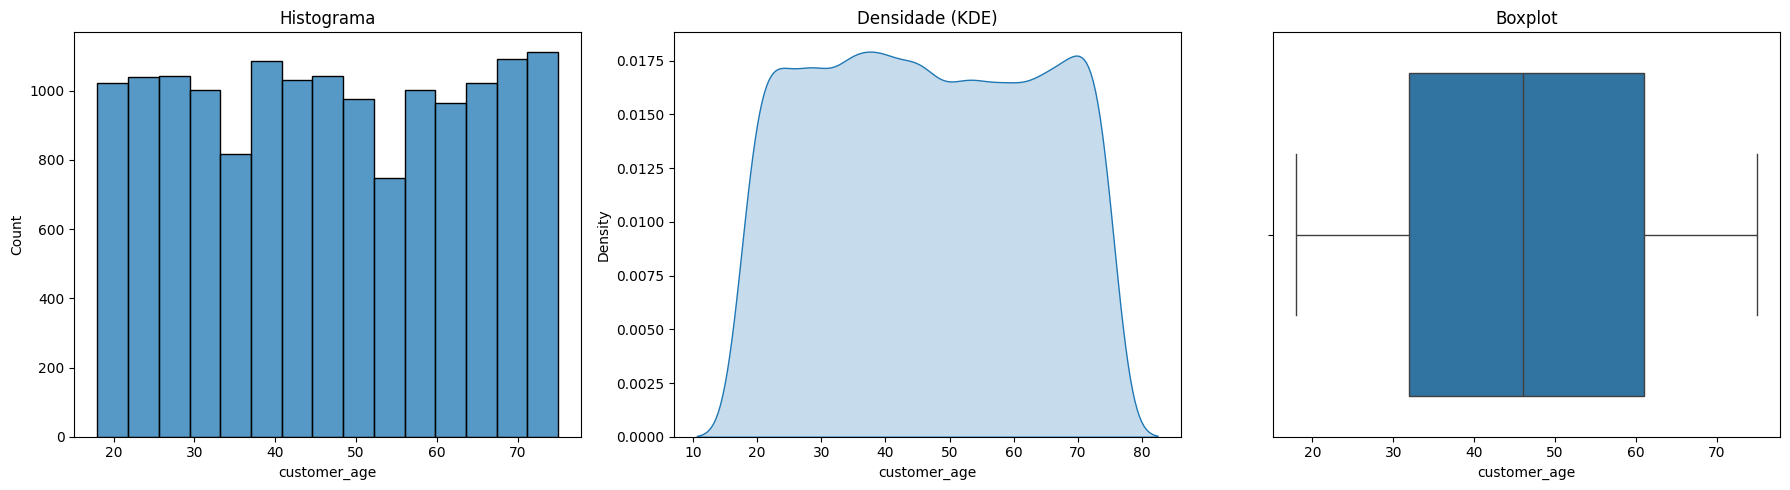

In [29]:
bins = int(np.ceil(np.log2(len(df['customer_age'])) + 1))

display(df['customer_age'].describe())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['customer_age'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['customer_age'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['customer_age'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

Ao analisar a estatística descritiva dos dados idade do consumidor, observa-se uma média de, aproximadamente, 47 anos, com a menor idade sendo 18 anos e a maior 75. Esse é um comportamento adequado para usuários de aplicativos, onde menores de 18 anos não tem acesso. O desvio-padrão é considerado elevado, com valor de 16,84 valores em torno da média, mostrando que temos grande variação na idade dos usuários.

Ao analisar o histograma, percebe-se que alguns valores destacam-se muito acima da maioria, levando a um comportamento semelhante a uma distribuição uniforme. A distribuição uniforme é simétrica, contudo nos dados apresentados, a media (46,56) é ligeiramente maior que a mediana (46), o que indica uma leve assimetria à direita.

Essa leve assimetria pode ser melhor visualizada no gráfico de densidade, o qual também mostra que tem distribuição platicútica, contudo não é perfeita, pois ainda apresenta picos.

O boxplot não identificou a presença de outliers, apesar do grande desvio-padrão.

ANÁLISE 2 - PONTUAÇÃO DE LEALDADE DO CLIENTE

count    15000.000000
mean        50.017658
std         28.771665
min          0.007172
25%         25.199828
50%         50.092268
75%         74.840432
max         99.989375
Name: customer_loyalty_score, dtype: float64

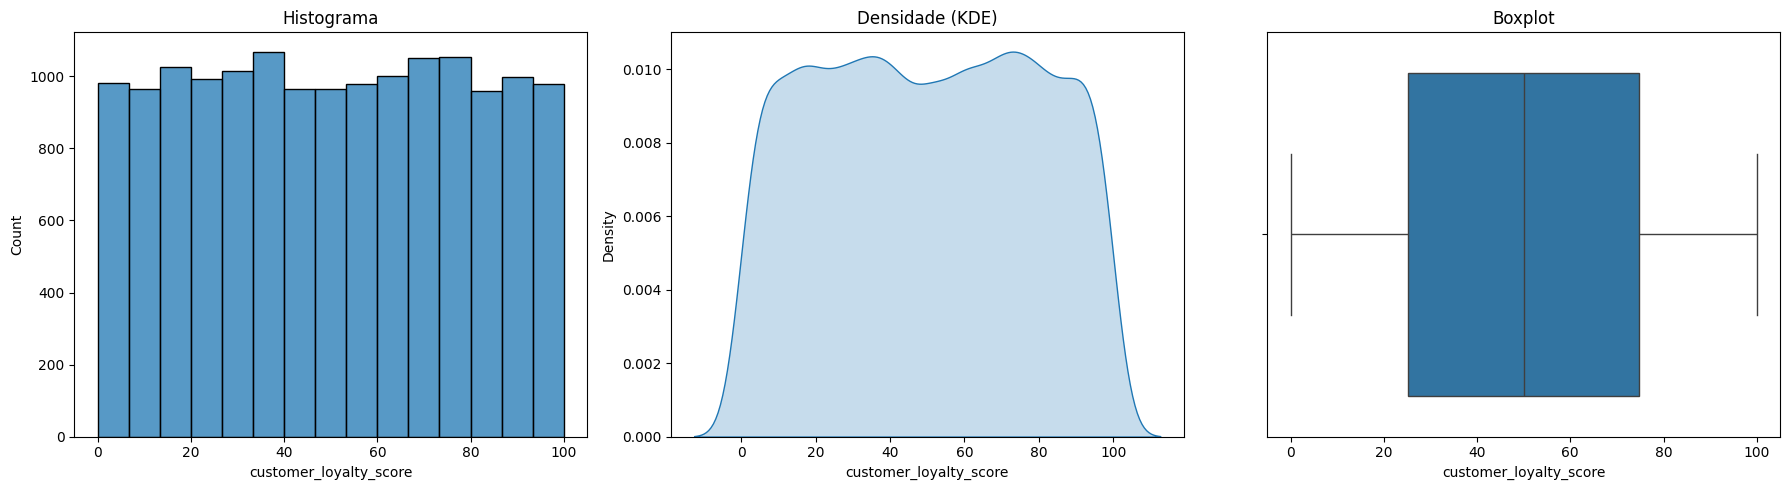

In [33]:
display(df['customer_loyalty_score'].describe())
bins = int(np.ceil(np.log2(len(df['customer_loyalty_score'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['customer_loyalty_score'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['customer_loyalty_score'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['customer_loyalty_score'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

Ao analisar a estatística descritiva dos dados de pontuação de lealdade do cliente, observa-se uma média de, aproximadamente, 50 pontos, com a menor pontuação sendo 0,007 e a maior 99,98. Esses valores refletem uma espécie de fidelidade do cliente ao estabelecimento. Isso mostra que clientes com baixos valores podem ser clientes novos ou comprar com pouca frequência, enquanto valores altos indicam que o cliente é fiel à loja. O desvio-padrão é considerado muito elevado, com valor de 28,77 valores em torno da média, mostrando que temos grande variação preferência dos usuários.

Ao analisar o histograma, percebe-se que a frequência dos valores ocupa uma posição muito parecida, levando a um comportamento semelhante a uma distribuição uniforme. A distribuição uniforme é simétrica, contudo nos dados apresentados, a media (50,01) é ligeiramente menor que a mediana (50,09), o que indica uma leve assimetria à esquerda.

Essa leve assimetria pode ser melhor visualizada no gráfico de densidade, o qual também mostra que tem distribuição platicútica, contudo não é perfeita, pois ainda apresenta picos.

O boxplot não identificou a presença de outliers, apesar do grande desvio-padrão.

ANÁLISE 3 - HORA DO PEDIDO

count    15000.000000
mean        11.470933
std          6.946134
min          0.000000
25%          5.000000
50%         11.000000
75%         18.000000
max         23.000000
Name: order_hour, dtype: float64

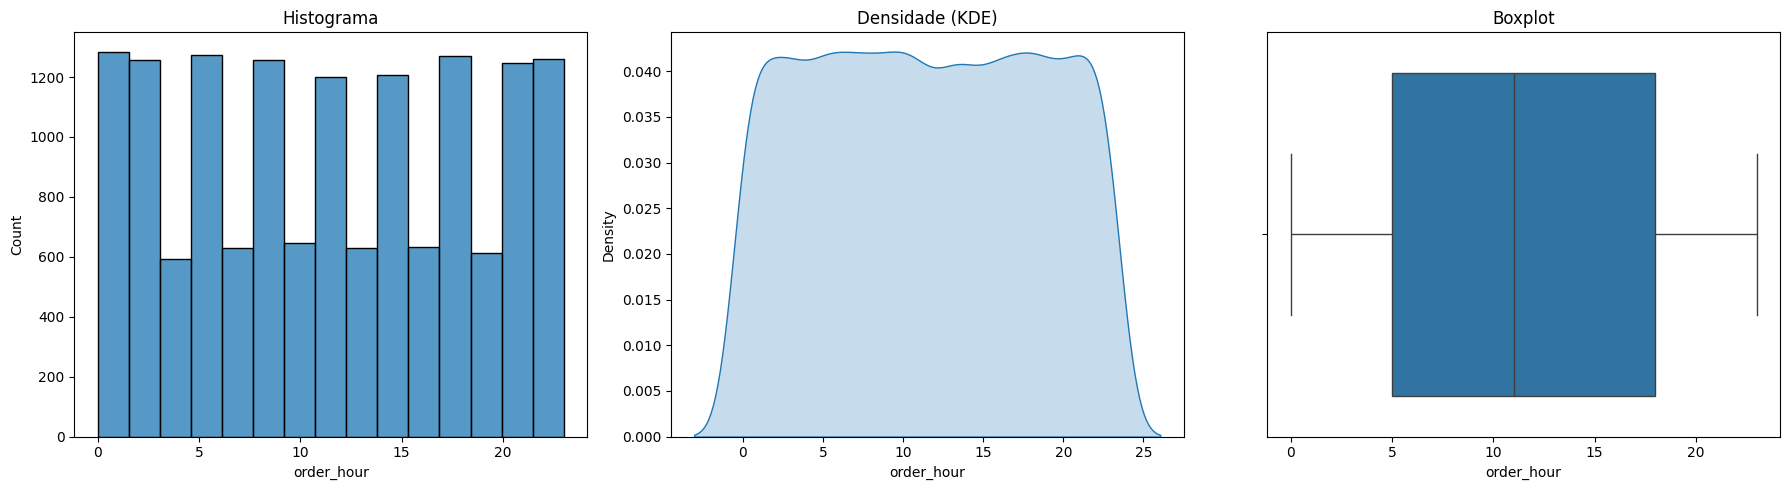

In [34]:
display(df['order_hour'].describe())
bins = int(np.ceil(np.log2(len(df['order_hour'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['order_hour'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['order_hour'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['order_hour'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

Ao analisar a estatística descritiva dos dados de pontuação da hora do pedido, observa-se uma média de, aproximadamente, 11 horas, com o menor horário sendo 0 (meia-noite) e o  maior 23 horas. Esses valores mostram que a demanda pelos aplicativos de entrega de comida ocorrem em todos os horários do dia, apesar de em quantidades diferentes.

O desvio-padrão é de 6,94, mostrando que coincide com o que seriam os horários de café da manhã e jantar, quando, além do almoço também ocorre muita procura.

Ao analisar o histograma, percebe-se que grande parte dos valores ficam em torno de uma frequência de 600, porém valores extremos de horário apresentam frequeências muito elevadas, levando a um comportamento semelhante a uma distribuição uniforme. A distribuição uniforme é simétrica, contudo nos dados apresentados, a media (11,47) é ligeiramente maior que a mediana (11), o que indica uma leve assimetria à direita.

Essa leve assimetria pode ser melhor visualizada no gráfico de densidade, o qual também mostra que tem distribuição platicútica, contudo não é perfeita, pois ainda apresenta picos, especialmente nas extremidades do gráfico.

O boxplot não indicou a presença de outliers.

ANÁLISE 4 - DISTÂNCIA DA ENTREGA EM KM

count    15000.000000
mean        20.133756
std         11.543488
min          0.103086
25%         10.133190
50%         20.228709
75%         30.047891
max         39.998739
Name: delivery_distance_km, dtype: float64

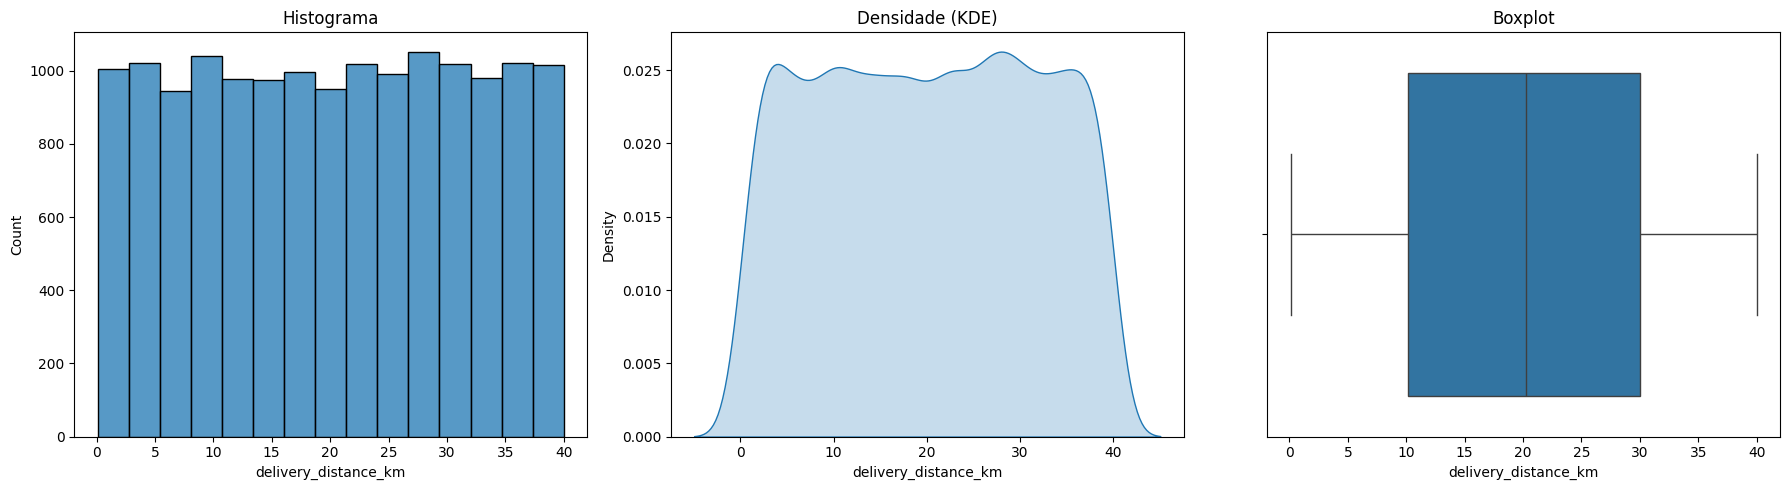

In [35]:
display(df['delivery_distance_km'].describe())
bins = int(np.ceil(np.log2(len(df['delivery_distance_km'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['delivery_distance_km'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['delivery_distance_km'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['delivery_distance_km'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

Ao analisar a estatística descritiva dos dados de distância do pedido, observa-se uma média de, aproximadamente, 20 km, com a menor distância sendo 0,103 km, e a maior 39,99 km. Isso evidencia que o cliente pode estar localizado ao lado da loja ou muito distante. O desvio-padrão é de 11,54, o que considerando o valor máximo encontrado, apresenta um grau médio de variação.

Ao analisar o histograma, percebe-se que grande parte dos valores ficam em torno de uma frequência de 600, havendo somente um ponto de pico, porém não muito distante da maioria das frequências, levando a um comportamento semelhante a uma distribuição uniforme. A distribuição uniforme é simétrica, contudo nos dados apresentados, a media (20,13) é ligeiramente menor que a mediana (20,28), o que indica uma leve assimetria à esquerda.

Essa leve assimetria pode ser melhor visualizada no gráfico de densidade, o qual também mostra que tem distribuição platicútica, contudo não é perfeita, pois ainda apresenta picos.

O boxplot não identificou a presença de outliers, além de confirmar a distribuição uniforme dos dados.

ANÁLISE 5 - TEMPO DE ENTREGA EM MINUTOS

count    15000.000000
mean        94.139267
std         33.597132
min         10.000000
25%         68.000000
50%         95.000000
75%        120.000000
max        180.000000
Name: delivery_time_minutes, dtype: float64

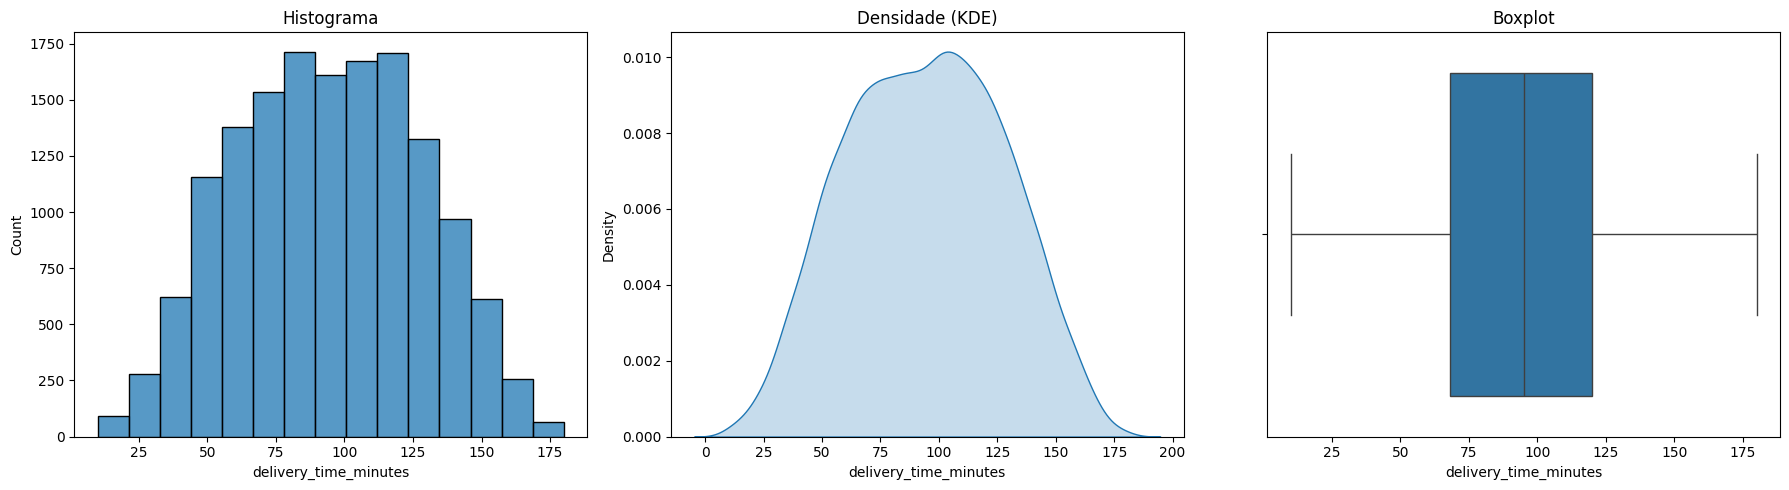

In [36]:
display(df['delivery_time_minutes'].describe())
bins = int(np.ceil(np.log2(len(df['delivery_time_minutes'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['delivery_time_minutes'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['delivery_time_minutes'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['delivery_time_minutes'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

Ao analisar a estatística descritiva dos dados de tempo de entrega, observa-se uma média de 94 minutos, com o menor tempo sendo de 10 minutos, e o maior de 180 minutos. Esse tempo elevado, faz com que a média seja puxada para cima, o que não representa um comportamento normal de serviços de entrega, ou pode significar problema de encerramento da entrega no aplicativo.

O desvio-padrão é de 33,59, o que representa uma grande variação de valores em torno da média.

Ao analisar o histograma, percebe-se que a maioria dos dados agrupados estão agrupados em torno da média, levando a um comportamento similar ao de uma distribuição gaussiana normal. Essa distribuição apresenta, historicamente um comportamento simétrico, contudo, nos dados estudados a média (94,14) e menor que a mediana (95), indicando uma leve assimetria à esquerda.

O boxplot não identificou a presença de outliers, além de confirmar a distribuição simétrica dos dados.

ANÁLISE 7 - ANÁLISE DE TRÁFEGO

count    15000.000000
mean         5.047500
std          2.806904
min          1.000000
25%          2.500000
50%          5.000000
75%          7.500000
max         10.000000
Name: traffic_level_score, dtype: float64

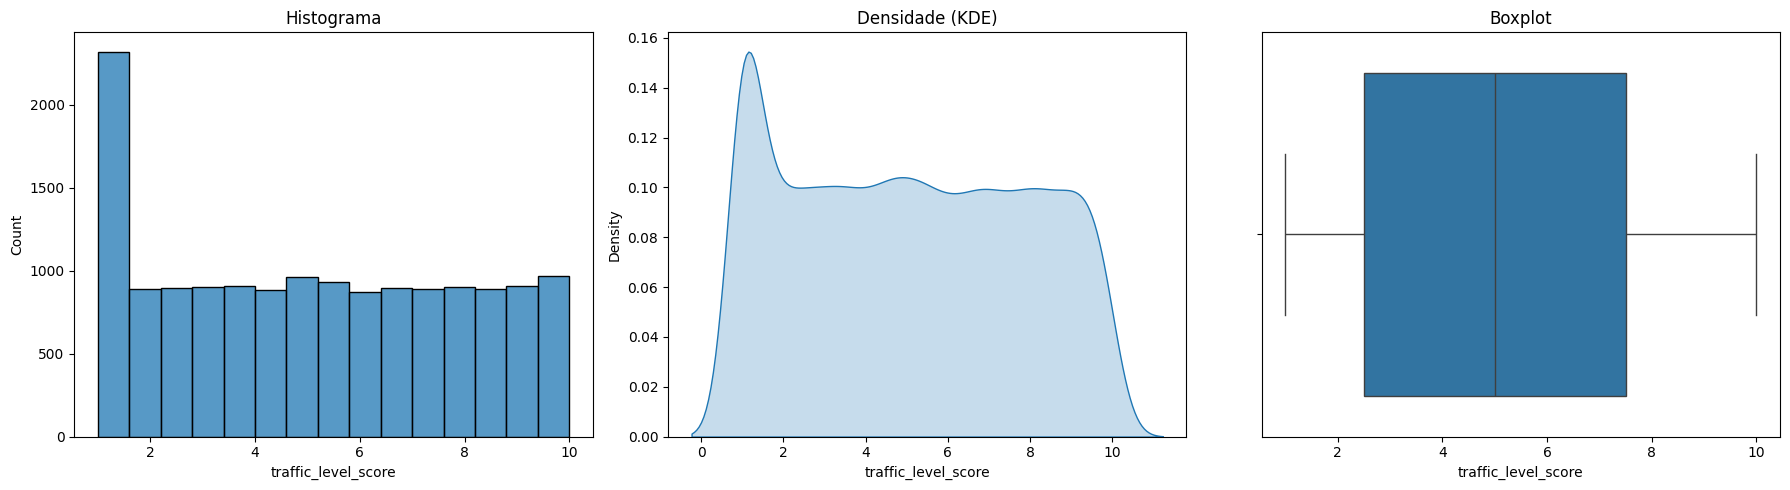

In [37]:
display(df['traffic_level_score'].describe())
bins = int(np.ceil(np.log2(len(df['traffic_level_score'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['traffic_level_score'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['traffic_level_score'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['traffic_level_score'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

A variável parece estar em uma escala de 1 a 10, onde valores maiores provavelmente indicam tráfego mais intenso. A média de 5,05 e a mediana de 5,0 são muito próximas, o que sugere que a distribuição está relativamente equilibrada em torno do centro da escala.

Os 50% centrais dos dados estão distribuídos entre 2,5 e 7,5, uma faixa ampla. Portanto, há bastante variação nos níveis de tráfego.
Como o mínimo é 1 e o máximo é 10, os dados ocupam praticamente toda a escala possível. Isso indica que o conjunto contém desde situações de tráfego muito baixo até tráfego muito alto.

Analisando o histograma, a distribuição apresenta um comportamento misto: há um pico muito forte no menor valor da escala e, depois disso, os valores ficam relativamente espalhados entre 2 e 10. Existe uma concentração muito alta no valor próximo de 1. A primeira barra tem aproximadamente 2.000 registros, muito acima das demais barras, que ficam em geral entre cerca de 500 e 650 registros. Isso indica que há muitos casos classificados como tráfego mínimo ou muito baixo.

A curtose provavelmente é negativa ou baixa, indicando uma distribuição platicúrtica: achatada, ampla e pouco concentrada em torno da média. Já o boxplot não mostra outliers.

ANÁLISE 8 - SEVERIDADE CLIMÁTICA

count    15000.000000
mean         5.010967
std          2.901365
min          0.000000
25%          2.500000
50%          5.000000
75%          7.600000
max         10.000000
Name: weather_severity_score, dtype: float64

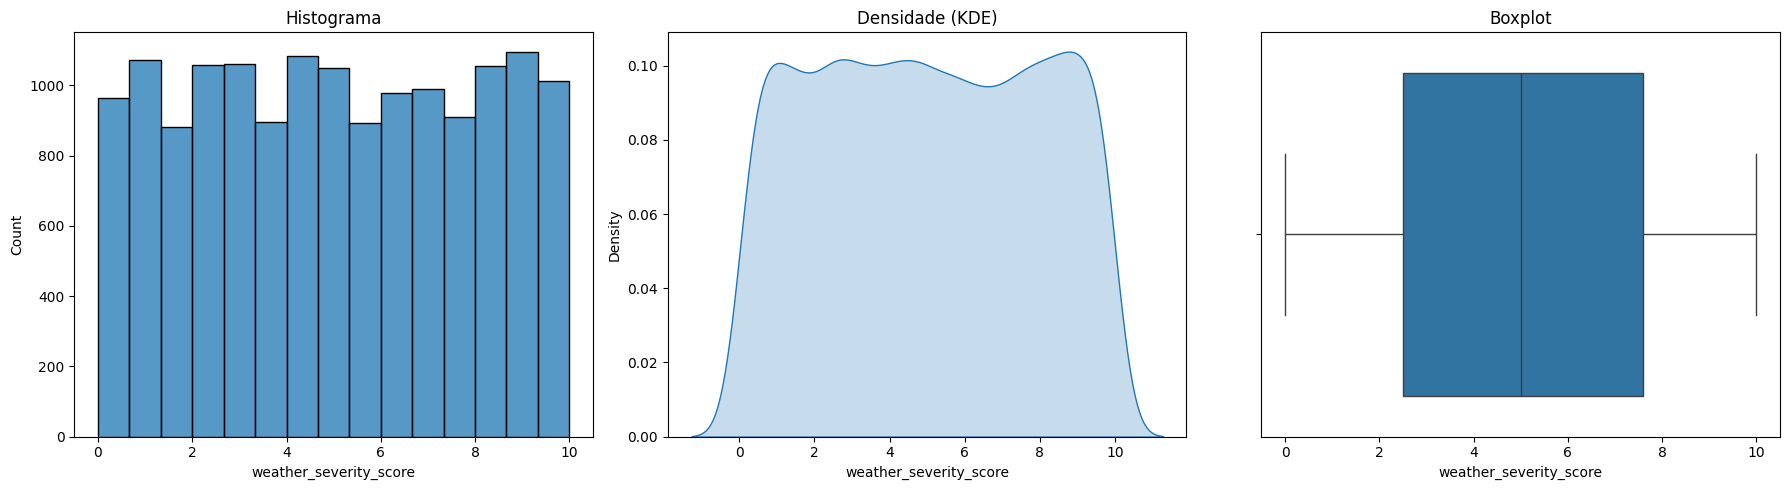

In [38]:
display(df['weather_severity_score'].describe())
bins = int(np.ceil(np.log2(len(df['weather_severity_score'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['weather_severity_score'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['weather_severity_score'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['weather_severity_score'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

ANÁLISE 9 -  NOTA DO RESTAURANTE

count    15000.000000
mean         4.096933
std          0.442340
min          2.300000
25%          3.800000
50%          4.100000
75%          4.400000
max          5.000000
Name: restaurant_rating, dtype: float64

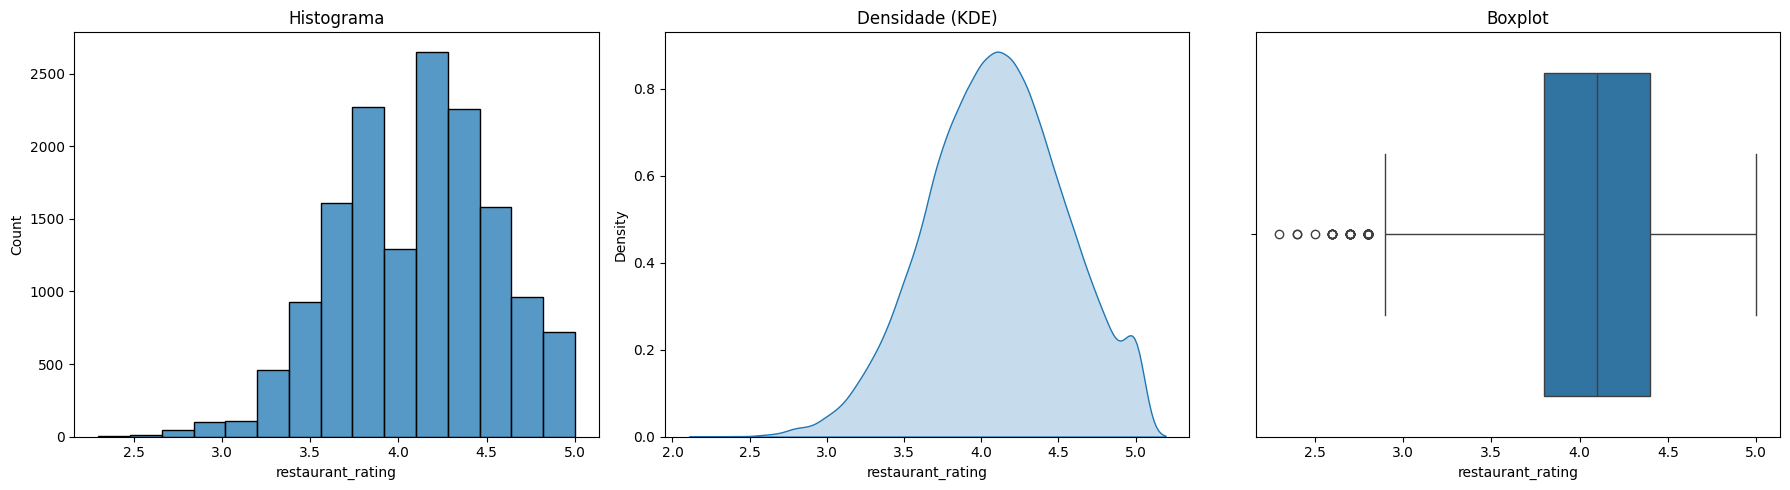

In [39]:
display(df['restaurant_rating'].describe())
bins = int(np.ceil(np.log2(len(df['restaurant_rating'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['restaurant_rating'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['restaurant_rating'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['restaurant_rating'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

A média (4,0969) e a mediana (4,1) são praticamente iguais, indicando que o centro da distribuição está em torno de 4,1. Isso mostra que a maioria dos restaurantes tem avaliações relativamente altas. O desvio-padrão de 0,4423 também mostra que as avaliações variam pouco em torno da média.

O histograma mostra uma concentração forte entre aproximadamente 3,7 e 4,6, com pico próximo de 4,1 a 4,2. Há poucos valores abaixo de 3,0 e também uma queda gradual após 4,5, embora ainda existam muitos registros próximos de 5,0.
O gráfico de densidade confirma esse padrão: a curva tem um pico claro próximo de 4,1, com formato parecido ao de uma distribuição normal, mas não perfeitamente simétrica. A cauda inferior, indo até 2,3, é mais longa do que a parte superior, que é limitada em 5,0. Por isso, há uma leve assimetria negativa, ou seja, à esquerda.

Como o máximo é 5,0, não há outliers superiores. Mas valores abaixo de aproximadamente 2,9 aparecem como outliers inferiores, o que é visível no boxplot.

Sobre a curtose, os dados estão bem concentrados ao redor da média, com um pico mais definido. Portanto, pode ser interpretada como mais próxima de uma distribuição mesocúrtica a levemente leptocúrtica, dependendo do valor numérico exato da curtose.

ANÁLISE 10 - NOTA DO CLIENTE

count    14850.000000
mean         3.993556
std          0.535016
min          1.500000
25%          3.600000
50%          4.000000
75%          4.400000
max          5.000000
Name: customer_rating, dtype: float64

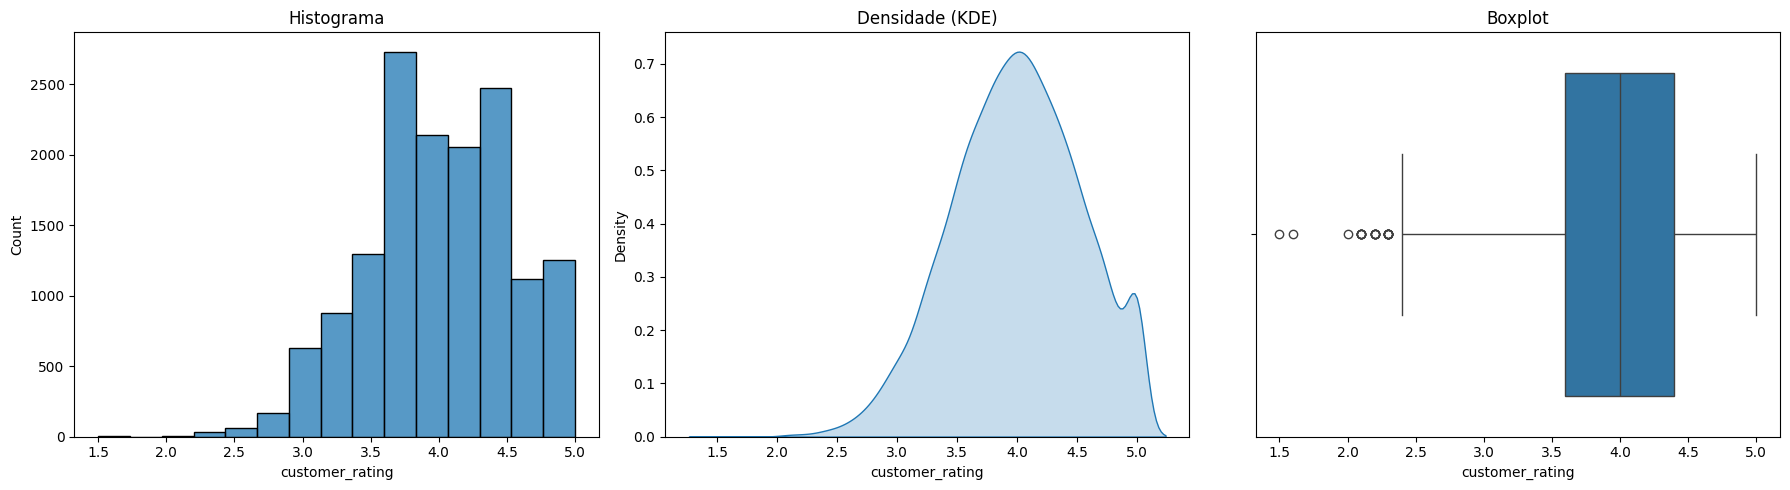

In [40]:
display(df['customer_rating'].describe())
bins = int(np.ceil(np.log2(len(df['customer_rating'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['customer_rating'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['customer_rating'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['customer_rating'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

O comportamento geral é de uma distribuição unimodal, com pico principal entre 4,0 e 4,1. A maior parte dos valores está concentrada entre 3,6 e 4,4, como mostra o boxplot.

A média (3,99) e a mediana (4,0) são praticamente iguais, o que indica que o centro da distribuição está bem definido em torno de 4. Porém, visualmente, há uma cauda mais longa à esquerda, porque existem algumas avaliações bem baixas, chegando até 1,5.

Isso significa que a distribuição apresenta assimetria negativa, ou seja, é levemente inclinada para a esquerda. A maioria das avaliações está em níveis altos, mas poucos valores muito baixos puxam a cauda inferior.

Como o valor máximo é 5,0, não há outliers superiores. Mas valores abaixo de 2,4 aparecem como outliers inferiores, o que é confirmado pelo boxplot.

Quanto à curtose, essa distribuição tende a ser mesocúrtica a levemente leptocúrtica. Ela tem um pico central bem visível, mas não extremamente estreito. A presença de alguns valores muito baixos na cauda esquerda aumenta um pouco o peso da cauda, mas a maior parte dos dados continua concentrada em torno de 4.

ANÁLISE 11 - VALOR DO PEDIDO

count    15000.000000
mean       113.954265
std         22.713411
min        100.000000
25%        100.000000
50%        100.000000
75%        124.153105
max        215.614574
Name: order_value, dtype: float64

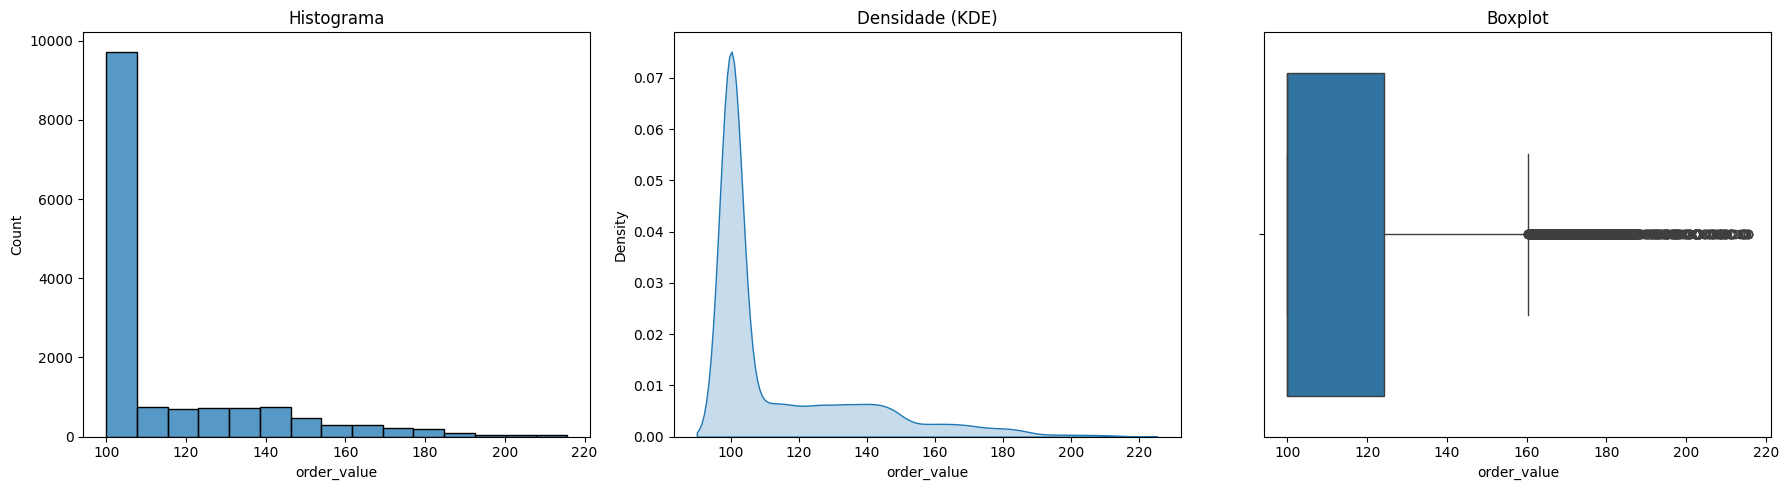

In [41]:
display(df['order_value'].describe())
bins = int(np.ceil(np.log2(len(df['order_value'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['order_value'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['order_value'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['order_value'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

A variável tem uma distribuição fortemente assimétrica à direita, com grande concentração no valor mínimo 100 e uma cauda longa para valores maiores.

O ponto mais importante é que Q1 = mediana = mínimo = 100. Isso significa que pelo menos 50% dos pedidos têm valor igual ou muito próximo de 100. O histograma confirma isso com uma barra extremamente alta em 100, indicando uma concentração muito grande nesse valor.

A média é 113,95, maior que a mediana 100, o que indica que os valores mais altos puxam a média para cima. Esse é um sinal clássico de assimetria positiva, ou seja, cauda à direita.

A distribuição não é normal. Ela tem formato de pico no limite inferior + cauda longa à direita. No gráfico de densidade, aparece um pico muito acentuado próximo de 100 e depois uma densidade baixa se estendendo até cerca de 215.

O boxplot reforça isso: a caixa começa em 100 e vai até cerca de 124,15, enquanto o bigode superior alcança aproximadamente 160. Acima disso há muitos pontos classificados como outliers superiores.

Sobre a curtose, essa variável tende a apresentar curtose elevada, ou seja, comportamento leptocúrtico. Isso ocorre por causa do pico muito forte em 100 e da presença de cauda direita com vários valores extremos. A distribuição é mais pontiaguda e com cauda mais pesada do que uma normal.

ANÁLISE 12 - TAXA DE DELIVERY

count    15000.000000
mean         7.493531
std          4.352771
min          0.000432
25%          3.704018
50%          7.458605
75%         11.278689
max         14.998370
Name: delivery_fee, dtype: float64

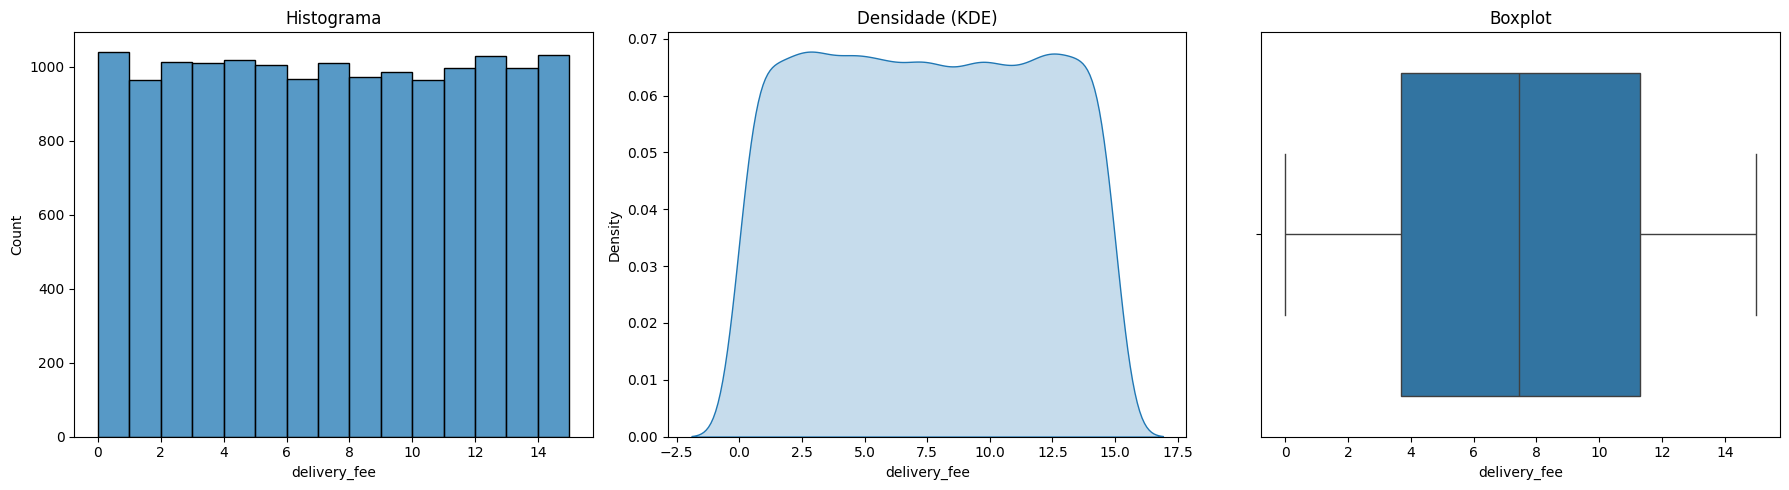

In [42]:
display(df['delivery_fee'].describe())
bins = int(np.ceil(np.log2(len(df['delivery_fee'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['delivery_fee'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['delivery_fee'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['delivery_fee'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

A média de 7,49 e a mediana de 7,46 são praticamente iguais. Isso indica que a distribuição está bem centralizada no meio da escala, sem assimetria relevante.

O histograma confirma esse comportamento: as barras ficam com frequências muito parecidas ao longo de todo o intervalo, de aproximadamente 0 a 15. Não há um pico dominante nem concentração em uma faixa específica.

A curva de densidade também é quase plana entre os limites da escala, com queda apenas nas extremidades. Esse formato é típico de uma distribuição uniforme.

O boxplot reforça a mesma leitura. A caixa vai de 3,70 a 11,28, com a mediana próxima ao centro. Os bigodes vão praticamente do mínimo ao máximo, e não aparecem pontos isolados. Portanto, não há evidência de outliers.

Sobre a curtose, a distribuição tende a ser baixa ou negativa, ou seja, platicúrtica. Isso acontece porque os dados estão espalhados de forma ampla e relativamente uniforme, sem pico central forte.

ANÁLISE 13 - DESCONTO NO PEDIDO

count    15000.000000
mean        14.932581
std          8.706253
min          0.000788
25%          7.279980
50%         14.857607
75%         22.521458
max         29.999893
Name: discount_amount, dtype: float64

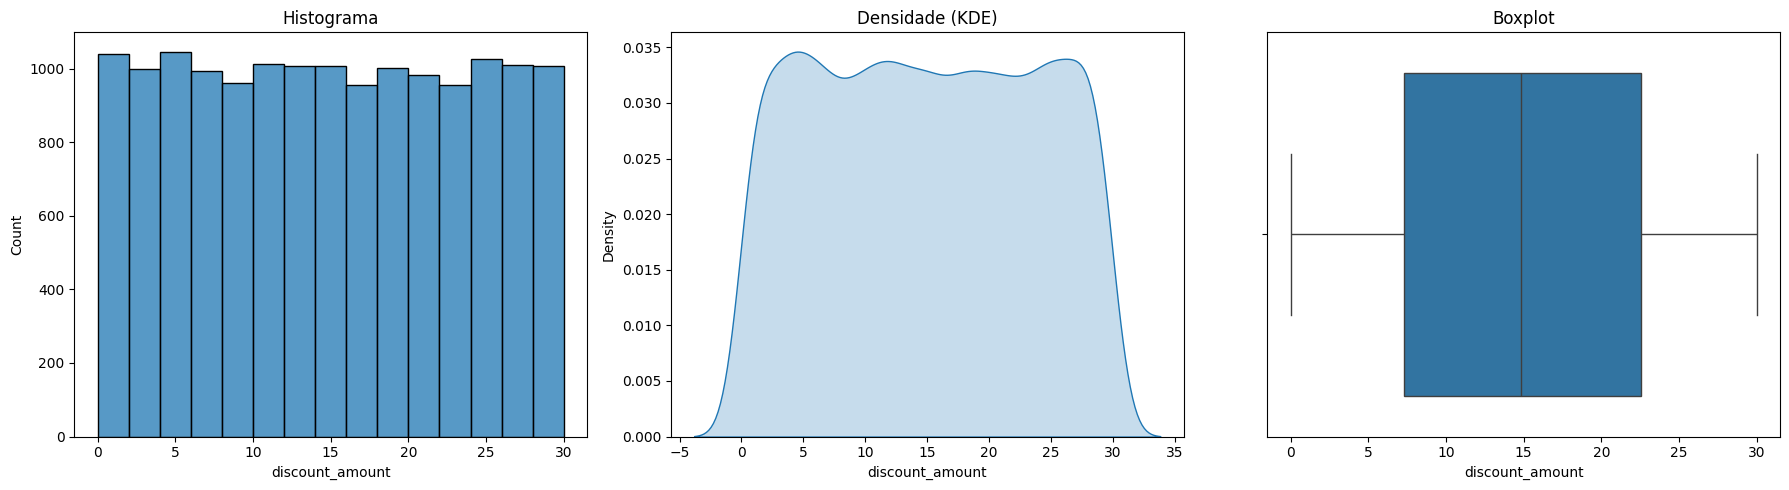

In [43]:
display(df['discount_amount'].describe())
bins = int(np.ceil(np.log2(len(df['discount_amount'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['discount_amount'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['discount_amount'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['discount_amount'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

A média (14,93) e a mediana (14,86) são praticamente iguais, o que indica uma distribuição bem centralizada no meio da escala. Como o intervalo vai de aproximadamente 0 a 30, o centro esperado seria perto de 15, exatamente onde os dados estão concentrados em termos de média e mediana.

O histograma mostra barras com frequências muito parecidas ao longo de toda a faixa de valores. Não há um pico dominante, nem concentração clara em valores baixos, médios ou altos. Isso é um forte indicativo de distribuição uniforme.

A curva de densidade também reforça esse comportamento: ela fica quase plana entre os limites da variável, com pequenas oscilações naturais. A queda nas extremidades ocorre por causa dos próprios limites da escala, próxima de 0 e 30.

O boxplot confirma a simetria e a ampla dispersão. A caixa vai de aproximadamente 7,28 a 22,52, e a mediana está quase no centro da caixa. Os bigodes vão praticamente do mínimo ao máximo, sem pontos isolados.

Quanto à curtose, a distribuição tende a ser baixa ou negativa, ou seja, platicúrtica. Isso acontece porque os dados não se concentram em torno da média; eles estão espalhados de maneira relativamente equilibrada por todo o intervalo. Esse é um comportamento típico de distribuições uniformes.

ANÁLISE 14 - QUANTIDADE DE ITENS NO PEDIDO

count    15000.000000
mean         6.489933
std          3.438123
min          1.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         12.000000
Name: number_of_items, dtype: float64

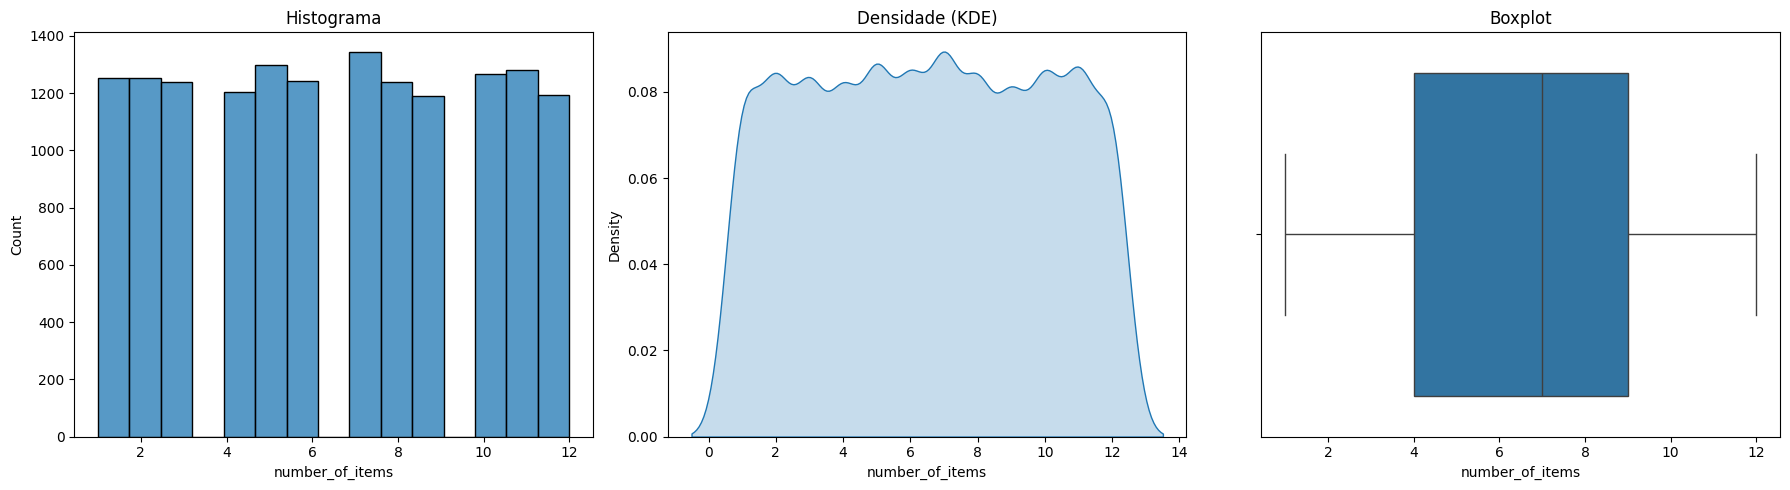

In [44]:
display(df['number_of_items'].describe())
bins = int(np.ceil(np.log2(len(df['number_of_items'])) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(
    df['number_of_items'],
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('Histograma')

# KDE
sns.kdeplot(
    df['number_of_items'],
    fill=True,
    ax=axes[1]
)
axes[1].set_title('Densidade (KDE)')

# Boxplot
sns.boxplot(
    x=df['number_of_items'],
    ax=axes[2]
)
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

Como se trata de uma contagem de itens, a variável é discreta, ou seja, assume apenas valores inteiros. O histograma mostra barras para cada quantidade de itens, de 1 a 12, com frequências muito parecidas. Isso indica que não há uma quantidade de itens claramente dominante.

A média é 6,49 e a mediana é 7. Esses valores estão próximos do centro da escala, sugerindo uma distribuição bem equilibrada. A leve diferença, com média um pouco menor que a mediana, indica no máximo uma assimetria negativa muito fraca, mas visualmente a distribuição é quase simétrica.

O boxplot confirma a ampla dispersão: metade dos pedidos tem entre 4 e 9 itens.

A curva de densidade também fica relativamente plana ao longo do intervalo, com pequenas ondulações causadas pelo fato de a variável ser discreta. Esse formato reforça o comportamento uniforme.

Quanto à curtose, ela tende a ser baixa ou negativa, ou seja, platicúrtica. Isso ocorre porque os valores estão espalhados de forma equilibrada entre 1 e 12, sem pico central forte.

ANÁLISE 15 - TAXA DE PEDIDOS ATRASADOS

array([False,  True])

delayed_delivery_flag
False    13580
True      1420
Name: count, dtype: int64

delayed_delivery_flag
False    90.533333
True      9.466667
Name: count, dtype: float64

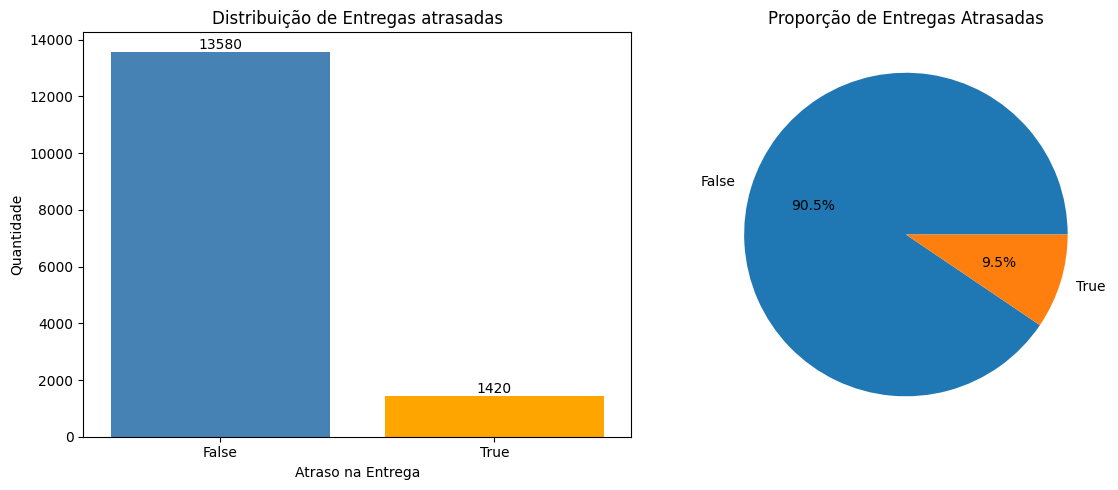

In [70]:
display(df['delayed_delivery_flag'].unique())
display(df['delayed_delivery_flag'].value_counts())
display(df['delayed_delivery_flag'].value_counts() / len(df)*100)

# Cria uma figura com 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(
    x='delayed_delivery_flag',
    data=df,
    ax=axes[0]
)

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

axes[0].set_title('Distribuição de Entregas atrasadas')
axes[0].set_xlabel('Atraso na Entrega')
axes[0].set_ylabel('Quantidade')
axes[0].patches[0].set_facecolor('steelblue')   # False
axes[0].patches[1].set_facecolor('orange') # True

# Gráfico de Pizza
df['delayed_delivery_flag'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1]
)

axes[1].set_title('Proporção de Entregas Atrasadas')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Ao analisar a taxa de pedidos atrasados, observa-se que 90,53% dos pedidos não chegam atrasados ao seu destino, e somente 9,47% atrasam.

Isso mostra que a previsão estimada pelo app é consistente e consegue atender a espectativa do cliente.

ANÁLISE 16 - USO DE CÓDIGO PROMOCIONAL

array([False,  True])

promo_code_used
False    8653
True     6347
Name: count, dtype: int64

promo_code_used
False    57.686667
True     42.313333
Name: count, dtype: float64

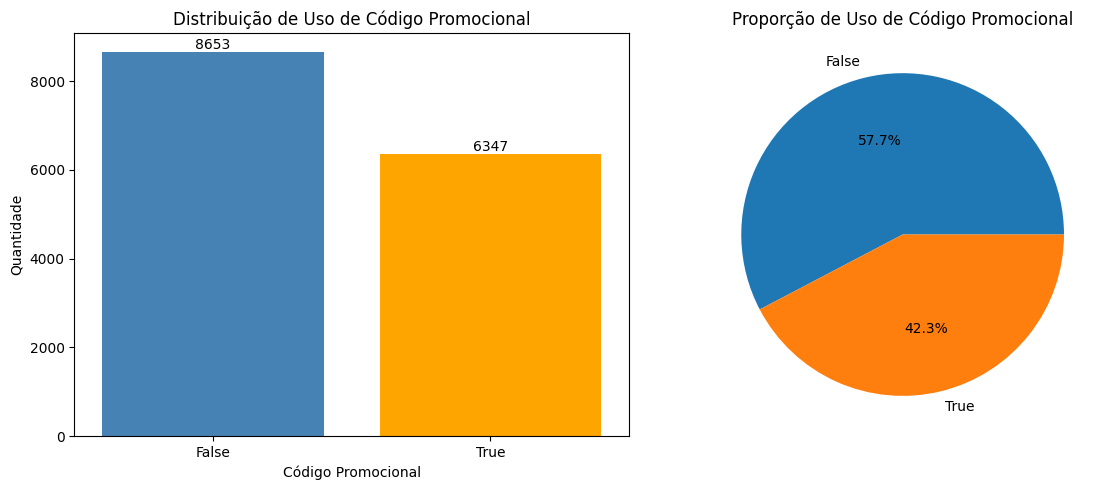

In [71]:
display(df['promo_code_used'].unique())
display(df['promo_code_used'].value_counts())
display(df['promo_code_used'].value_counts() / len(df)*100)

# Cria uma figura com 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
sns.countplot(
    x='promo_code_used',
    data=df,
    ax=axes[0]
)

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

axes[0].set_title('Distribuição de Uso de Código Promocional')
axes[0].set_xlabel('Código Promocional')
axes[0].set_ylabel('Quantidade')
axes[0].patches[0].set_facecolor('steelblue')   # False
axes[0].patches[1].set_facecolor('orange') # True

# Gráfico de Pizza
df['promo_code_used'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1]
)

axes[1].set_title('Proporção de Uso de Código Promocional')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Análise Multivariada

Nesta seção, você deve plotar pelo menos **10 visualizações multivariadas**. O objetivo é investigar correlações e comportamentos subjacentes no conjunto de dados.
Naturalmente, algumas visualizações podem revelar resultados esperados; no entanto, você deve identificar pelo menos **UM** comportamento não óbvio nos dados.

Siga estas etapas ao criar suas visualizações:
1. Formule uma hipótese. Explique por que você escolheu essas variáveis específicas e o que espera descobrir por meio de sua relação;
2. Determine qual tipo de visualização é mais adequado;
3. Relate as descobertas e discuta se elas corroboram ou não a hipótese formulada.


### Dicas

Nesta seção, vá além de explorações simples. Por exemplo, considere aplicar técnicas como PCA, t-SNE, ou outras não abordadas nas aulas. O objetivo é cultivar um pensamento crítico em relação à análise de dados e ao nosso trabalho.

### Importante

É estritamente proibido criar visualizações multivariadas utilizando variáveis que não foram incluídas na seção anterior (análise univariada).

Nesta seção, você deve **aprimorar 5 visualizações multivariadas** apresentadas na seção anterior do relatório.
O objetivo é melhorá-las para que possam ser apresentadas efetivamente a um público não familiarizado com o conjunto de dados ou com análise de dados.
**Portanto, certifique-se de que tamanho, cores, texturas e outros elementos visuais sejam adequados e transmitam a informação pretendida ao público.**

Para cada gráfico final, siga estas etapas:
1. Apresente o gráfico;
2. Forneça uma descrição da visualização, destacando as principais conclusões que podem ser extraídas dela.


**Dica**: consulte o checklist baseado no trabalho de Evergreen para garantir que suas visualizações sigam as melhores práticas de clareza e impacto.

# Pipeline